# Session 1: the Brain Imaging Data Structure (BIDS)

Welcome to our first neuroimaging lesson. In this session, we will learn the basics of practical neuroimaging.

The lesson is organised around **three main themes**:

  1. **Reproducibility** in Neuroscience: Jupyter Notebooks and Neurodesk

  2. How do we open and manipulate **neuroimaging data**?

  3. How do we organise (and understand) a **neuroimaging dataset**?



## 1. Reproducibility in neuroscience: Jupyter notebooks and Neurodesk

### 1.1 The reproducibility challenge in neuroimaging

Modern neuroimaging analyses depend on a large ecosystem of specialised tools, from image reconstruction and preprocessing pipelines to statistical modelling packages. Installing and managing these tools on your own machine is notoriously difficult: tools behave differently across **operating systems** (Windows, macOS, Linux), and some run only on Linux; results can vary across **software versions**, even minor ones; setting up a working environment often takes hours or days, and can break unexpectedly with a system update; and collaborators and reviewers cannot easily re-run your analyses if their setup differs from yours (and it most likely will).

This is a **reproducibility problem**. Two researchers following the same protocol with different software configurations may obtain different results. In a field where findings directly inform clinical and scientific decisions, this matters enormously.

The good news: this problem has a solution.

### 1.2 Neurodesk: reproducible neuroimaging in the browser

[**Neurodesk**](https://www.neurodesk.org/) solves the installation and reproducibility problem by providing a **containerised computing environment** with hundreds of neuroimaging tools pre-installed and version-locked. Instead of installing tools and downloading data on your own machine, you access a standardised environment that runs identically on any computer, anywhere in the world.

No installation is required: all tools are ready to use from day one. Everyone works with the exact same version-controlled software, which makes results reproducible. And it is free and open-source, accessible online at [neurodesk.org](https://www.neurodesk.org/).

>**For this course**, Neurodesk is hosted for you by **[EGI](https://www.egi.eu/services/research/)** (European Grid Infrastructure)!

We will use **two working interfaces in Neurodesk:**

| Interface | Description | When we use it |
|---|---|---|
| 🖥️ **Neurodesktop** | A full graphical desktop (like a virtual computer) running in your browser | Running GUI tools (e.g. MRIcron), using the terminal, browsing files |
| 🐍 **VSCode** | A notebook and code editor interface | Writing and running Python analyses in Jupyter notebooks (like this one!) |

In this course, we will primarily work in VScode to open **Jupyter notebooks**, but we will regularly switch to **Neurodesktop** when we need graphical or command-line tools.

#### Getting started with Neurodesk

When you open the link provided by your instructor, you will land on the **Neurodesk main page**: a JupyterLab interface that serves as your hub for everything in this course. From here you can open notebooks, a code editor, a terminal, and the full desktop environment.

---

**Opening VS Code**

The same VS Code editor you are working in right now is directly available from Neurodesk:

1. Click the **`+`** button in the top-left toolbar to open the **Launcher** tab
2. In the Neurodesk section, click **VS Code**

<img src="assets/sess-1a/figures/launcher-vscode.png" width="700" style="border: 1.5px solid black;"/>

A new browser window will open with a VS Code editor, identical to the one you are using now. You can close it for the moment; we will work primarily from within this notebook.

---

**Opening the Neurodesktop (full Linux desktop)**

Neurodesk also provides a **complete Linux-based desktop environment** running entirely in your browser. This is what we will use whenever we need to browse folders, open graphical tools like MRIcron, or run terminal commands.

1. Click the **`+`** button again to open the Launcher tab
2. This time, click **Neurodesktop** (the first icon in the Neurodesk section)

<img src="assets/sess-1a/figures/launcher-neurodesktop.png" width="700" style="border: 1.5px solid black;"/>

A setup page will appear with connection options. Click **Desktop RDP**, then wait a moment while the desktop initialises.

<img src="assets/sess-1a/figures/neurodesktop-init.png" width="700" style="border: 1.5px solid black;"/>

After a few seconds, a full desktop will appear in your browser.

This is a real Linux PC hosted by EGI, running entirely online with no installation on your machine. You will see a taskbar at the bottom with access to a file manager, a terminal, and all neuroimaging tools.

<img src="assets/sess-1a/figures/neurodesktop-desktop.png" width="700" style="border: 1.5px solid black;"/>

This is the environment we will switch to whenever instructions say *"open Neurodesktop"* (you will see this icon 🖥️).

Feel free to explore it now: click through the applications menu to get a sense of what is available. Neurodesk ships with a wide range of neuroimaging tools, and you are welcome to try them out.

**Want to learn more?** See the [Neurodesk website](https://www.neurodesk.org/) for an overview of the project, the [getting started guide](https://www.neurodesk.org/docs/getting-started/) for step-by-step setup instructions, and the [full documentation](https://www.neurodesk.org/docs/) for a reference of all tools and features.


### 1.3 Jupyter notebooks: your scientific lab book

A **Jupyter notebook** is an interactive document that combines two types of cells. **Markdown cells** (like the one you are reading now!) contain formatted text, images, equations, and links; they are used to explain concepts, provide context, and guide you through the analysis. **Code cells** contain executable Python code; you run them directly in the notebook, and the output (plots, tables, printed values) appears immediately below the cell. To run a cell, select it and press `SHIFT + ENTER`, or click the play button next to the top-left corner of the cell you want to run.

This combination makes notebooks ideal for science and teaching. Analyses are interleaved with explanations, so you always understand what the code is doing and why. Anyone with the same environment can re-run the notebook cell by cell and obtain the same results. And notebooks can be distributed as files, published on GitHub, or rendered as web pages.

> While traditional Python scripts (`.py` files) are better suited for large, production-level analyses and software packages, notebooks are excellent for **learning**, **communicating results**, and **prototyping**, which is exactly what we will use them for here.

In this course, we run Jupyter Notebooks using VScode.

### 1.4 How we will work in these sessions

Here is the workflow we will follow throughout the course:

1. **Read the markdown cells** to understand the concept or task at hand
2. **Run the code cells** (`Shift + Enter`) to perform the analysis and see the output
3. **Switch to Neurodesktop** when instructed, to use graphical tools (e.g. MRIcron for image viewing) or command-line tools (e.g. dcm2niix for format conversion)
4. **Answer the questions** embedded in the notebook to check your understanding
5. **Complete the exercises** at the end of each session

To help you navigate at a glance, section titles use the following icons:

| Icon | Meaning |
|---|---|
| 🖥️ | **Switch to Neurodesktop**: you will need to open the Neurodesktop environment for this section |
| 🐍 | **Python**: this section contains code cells to run in the notebook |
| 📝 | **Practice**: exercises and tasks for you to complete |


## 2. How do we open and manipulate neuroimaging data?

Before we can analyse brain images, we need to understand how neuroimaging data are stored, how to open them, and how to load and inspect them in Python. 

In this section, we will cover the most common neuroimaging file formats, learn to visualise brain images with MRIcron, and use **nilearn** to load, inspect, and plot NIfTI files.

### 2.1 Neuroimaging file formats

When data are collected on an MRI scanner, they are saved in one of several raw formats. The two most common are **DICOM** (`.dcm`), the standard output format of most MRI scanners, and **PAR/REC**, a format specific to Philips MRI scanners. A DICOM acquisition is split across many individual files (one per slice or volume), with metadata embedded in each file's header; it is widely used in clinical settings but cumbersome to work with directly in research. PAR/REC stores image data (`.rec`) separately from acquisition parameters (`.par`).

You will sometimes also see files with an **`.IMA`** extension: these are simply DICOM files exported by **Siemens** scanners (the name is short for *image*). The content follows the standard DICOM specification, so any tool that reads `.dcm` (`dcm2niix`, MRIcron, pydicom, etc.) will happily read `.IMA` too — it is the same format under a different name. The DICOM data we convert in Section 3.3 are in this form.

These raw formats are not ideal for analysis: they are complex, often vendor-specific, and difficult to handle programmatically. For this reason, research neuroimaging almost universally converts raw scanner data to the **NIfTI** format before any analysis.

<img src="assets/sess-1a/figures/fileformats-comparison.png" width="1200" style="border: 1.5px solid black;"/>

**NIfTI** (Neuroimaging Informatics Technology Initiative) is the standard file format in neuroimaging research. It comes in two flavours: `.nii`, a single file containing both the image data and the header, and `.nii.gz`, a gzip-compressed version (much smaller on disk, and by far the most common in practice).

NIfTI is simple (all information, image data and metadata, lives in one file), open (not tied to any specific vendor or scanner manufacturer), and universally supported: virtually every neuroimaging software tool can read and write NIfTI files. Each file also includes an **informative header** with essential metadata: image dimensions, voxel size, spatial orientation, data type, and more.

A NIfTI image is essentially a **3D (or 4D) array of voxel intensity values**, stored alongside a header that tells software how to interpret and display those values. For structural MRI (T1-weighted), the array is 3D. For functional MRI (BOLD), it is 4D: three spatial dimensions plus time.

### 2.2 🖥️ Viewing brain images: MRIcron in Neurodesktop

Before working with images in Python, it is useful to simply *look* at them. **MRIcron** is a lightweight, easy-to-use viewer for NIfTI images. We will use it to build an intuition for what brain data looks like before we start manipulating it programmatically.

> **Tip: quick NIfTI preview in VS Code.** If you have the [NiiVue extension](https://marketplace.visualstudio.com/items?itemName=niivue.niivue-vscode) installed (it is available in Neurodesk's VS Code), you can preview any `.nii.gz` file directly from the Explorer panel: just click on it and an MRIcron-style viewer opens in a new tab. This is handy for a quick look, but in this section we use MRIcron because it is a widely used standalone tool you will encounter throughout your career.

**Instructions to open MRIcron in Neurodesktop:**

1. Switch to **Neurodesktop** in your browser
2. Click on **Applications** in the taskbar --> **Neurodesk** --> **Visualisation** --> select **mricronGUI**

> **NOTE:** starting MRIcron will take some time. You will see a black window (a terminal) executing some commands. Let it run; it is downloading the software you asked for.

<img src="assets/sess-1a/figures/start-mricron.png" width="680" style="border: 1.5px solid black;"/>

3. Once MRIcron opens, go to **File → Open** and navigate to the course data folder:

```
/home/jovyan/HBI/assets/sess-1a/nifti/MNI152_T1_1mm.nii.gz
```

This is the **MNI152 ICBM 152 T1 template**, a standard brain template created by averaging 152 T1-weighted structural scans from the Montreal Neurological Institute (MNI). It is one of the most commonly used reference spaces in neuroimaging.

Now that we have opened our first brain image, let's explore it.

In the three orthogonal views (axial, coronal, sagittal), click anywhere in the image to move the crosshair. By moving the crosshair you can see different slices of the data (notice the changes in the x, y and z coordinates).

You can also **right-click** anywhere on the image. Look at the bottom-left of the MRIcron window: you will see a field labelled **Intensity range** showing a number. That number is the **raw voxel value** at the location you clicked: the actual data value stored in that voxel, which determines the colour you see on screen. In a structural MRI like this one, brighter areas have higher intensity values (more signal), while dark areas (e.g. background, CSF) have values close to zero.

<img src="assets/sess-1a/figures/mricron-ir.png" width="680" style="border: 1.5px solid black;"/>

#### The NIfTI header

As we mentioned before, NIfTI images come with a **header**: a compact block of metadata stored at the start of the file that tells any software how to interpret the raw voxel data. The header records the **voxel size** (e.g. 1×1×1 mm, i.e. how much brain tissue each voxel represents), the **image dimensions** (the number of voxels along each axis), the **spatial orientation** (how the voxel grid maps onto physical space, i.e. which direction is left/right, up/down, front/back), the **data type** (how the intensity values are stored, e.g. 8-bit integer, 32-bit float), and, for functional images, the **TR** (repetition time, i.e. the time between consecutive volumes).

**Reading the header in MRIcron:** go to **Window → NIfTI Header**. A panel will appear with several tabs; open the **Dimensions** tab. Note down the values you see: the image dimensions (I, J, K Space), the voxel spacing, and the data type. You will use these to verify the output in the next Python section.

The `dim` array is the most important part of the header for understanding the shape of your data. It has 8 entries:

| Field | Meaning | `MNI152_T1_1mm` | Example (BOLD) |
|---|---|---|---|
| `dim[0]` | Number of dimensions in use | `3` | `4` |
| `dim[1]` | Size along **i**, I Space (left–right) | `197` | `64` |
| `dim[2]` | Size along **j**, J Space (front–back) | `233` | `64` |
| `dim[3]` | Size along **k**, K Space (bottom–top) | `189` | `40` |
| `dim[4]` | Number of **time points** (volumes) | `1` | `200` |
| `dim[5]` | 5th dimension; rarely used; can encode multiple echo times or phase-encoding directions | `1` | `1` |
| `dim[6]` | 6th dimension; typically unused in standard acquisitions | `1` | `1` |
| `dim[7]` | 7th dimension; typically unused in standard acquisitions | `1` | `1` |

A few things to note. **i, j, k** are *voxel* coordinates (array indices), not physical coordinates; the header's affine matrix handles the conversion from (i, j, k) to real-world millimetre coordinates (x, y, z). For a structural T1, **dim[4] = 1**: there is only one volume. For a BOLD run it is the number of TRs acquired (e.g. 200 means 200 brain volumes over time). **dim[5–7]** are almost always `1` in standard neuroimaging data; they exist in the NIfTI specification to support specialised acquisitions such as multi-echo fMRI (where dim[5] encodes echo number) or diffusion MRI with multiple b-values, but you will rarely need to worry about them.

The companion array **`pixdim`** stores the physical size of each step along each dimension (labelled **Spacing** in the MRIcron panel): `pixdim[1–3]` give the voxel size in mm (1 mm isotropic for the MNI152 template), and `pixdim[4]` gives the TR in seconds for functional data.

#### 📝 Practice: the AAL atlas

Now let's look at a different type of image: a **brain atlas**.

<img src="assets/sess-1a/figures/mricron-aal.png" width="680" style="border: 1.5px solid black;"/>

The [AAL atlas](https://www.gin.cnrs.fr/en/tools/aal/) (Automated Anatomical Labeling) is one of the most widely used brain parcellations in neuroimaging research. It divides the brain into **166 anatomical regions**, each assigned a unique integer label. A copy is included in the course data folder.

**Step 1: Open the AAL atlas as a standalone image**

In MRIcron, go to **File → Open** and navigate to:

```
/home/jovyan/HBI/assets/sess-1a/nifti/AAL3v2.nii
```

1. **Inspect the header.** Go to **Window → NIfTI Header** and note down the image dimensions (`dim[1]`, `dim[2]`, `dim[3]`), the voxel size (`pixdim[1–3]`), and the data type.

2. **Explore the image visually.** Move the crosshair around. Notice how the image looks very different from the MNI152 structural brain you opened earlier.

3. **Right-click in several locations** and note the **Intensity range** value at the bottom-left. Try clicking in the background (outside the brain), in a few different cortical regions, and in subcortical areas.

> **Questions:**
> 1. What values do you see? Are they continuous (any decimal number) or discrete (only whole numbers)?
>
> 2. What do you think those numbers represent? How is this different from the intensity values in the MNI152 structural image?
>
> 3. Why might it be important to always know what *kind* of NIfTI file you are working with before interpreting its values?

**Step 2: Overlay the atlas on the MNI152 template**

Now close the AAL atlas and reopen the MNI152 template (**File → Open** → `MNI152_T1_1mm.nii.gz`). Then go to **Overlay → Add** and select the AAL file (`AAL3v2.nii`). You should see the atlas regions overlaid as coloured patches on top of the anatomical image.

Move the crosshair around and notice how each coloured region corresponds to a different brain area and each has its own integer label. We will do exactly this kind of overlay programmatically in Python in Section 2.5.

### 2.4 🐍 Working with NIfTI files in Python: nilearn

While graphical tools like MRIcron are useful for quick visualisations and quality checks, neuroimaging analyses require programming. The tools of choice have shifted considerably over the past few decades.

For a long time, neuroimaging was dominated by **command-line (bash) tools** such as FSL, FreeSurfer, and ANTs, which are called from the terminal and chain together into shell scripts. These tools are still widely used today and remain extremely robust; you will encounter them throughout this course and your research career.

Alongside these, **MATLAB** became the dominant programming language for neuroimaging analysis, largely through packages like SPM (Statistical Parametric Mapping) and FieldTrip. For many years, MATLAB was essentially the standard.

Over the last decade or so, however, the field has shifted significantly towards **Python**. The reasons behind this shift are beyond the scope of this course, but the key advantages of Python over MATLAB are worth knowing. Python is **open source and free**: the language costs nothing, and neither do its packages (no licence fees, no institutional restrictions). It has a **massive community**: Python is one of the most widely used programming languages in the world, which means an enormous ecosystem of tutorials, forums, and documentation. Package **installation is straightforward**: tools like `pip` and `conda` let you install specialised packages with a single command. And the **scientific Python ecosystem** (NumPy, SciPy, pandas, matplotlib, scikit-learn...) covers virtually any analytical need, with the neuroimaging community having built dedicated packages on top of it.

[**nilearn**](https://nilearn.github.io/) is a prime example: a community-developed Python package built specifically for neuroimaging. It is our main tool in this course.

> 📖 **nilearn resources (bookmark these):**
> - [Documentation home](https://nilearn.github.io/stable/): user guide, tutorials, and API reference
> - [API reference](https://nilearn.github.io/stable/modules/reference.html): every function, parameter, and return value
> - [Examples gallery](https://nilearn.github.io/stable/auto_examples/index.html): worked, runnable examples for virtually every use case
>
> Get into the habit of looking up each function as you encounter it. Understanding a function's full signature (what parameters it accepts, what it returns, what the defaults are) is a crucial skills when writing your code.

In this section, we will use nilearn to:
1. **Load a NIfTI image** into Python
2. **Inspect the header** (the same file you opened in MRIcron, now loaded in Python; the values should match exactly)
3. **Plot the image** statically and interactively

In [1]:
! pip install nilearn # This runs a terminal command to install nilearn in the current environment

In [2]:
import nibabel as nib
import numpy as np

# Load the MNI152 T1 template — the same file you opened in MRIcron in Section 2.3
# docs:      https://nipy.org/nibabel/reference/nibabel.loadsave.html
# signature: nib.load(filename, mmap=True, keep_file_open=False)
img = nib.load('assets/sess-1a/nifti/MNI152_T1_1mm.nii.gz')

# Key header fields at a glance
print("Shape (i, j, k) :", img.shape)
print("Voxel size (mm)  :", img.header.get_zooms())
print("Data type        :", img.header.get_data_dtype())
print()

# Full NIfTI header — cross-check these values against the MRIcron Dimensions panel from Section 2.3
print(img.header)

Shape (i, j, k) : (197, 233, 189)
Voxel size (mm)  : (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data type        : uint8

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 197 233 189   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 1. 1. 1. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d      

The output shows the NIfTI header of the same file you explored in MRIcron in Section 2.3. Cross-check a few values against what you noted there; they should match exactly. The shape is 197 × 233 × 189 voxels (a 3D volume with no time dimension), the voxel size is 1 × 1 × 1 mm (1 mm isotropic, consistent with a structural T1-weighted image), and the data type is `uint8` (unsigned 8-bit integer), meaning intensity values run from 0 to 255.

> 📝 **nilearn convenience function:** nilearn ships the same template. `datasets.load_mni152_template(resolution=1)` loads the same ICBM 152 image. For standardised templates like this one, nilearn's fetch functions are often more convenient than managing file paths manually.

Now let's look at the image itself:

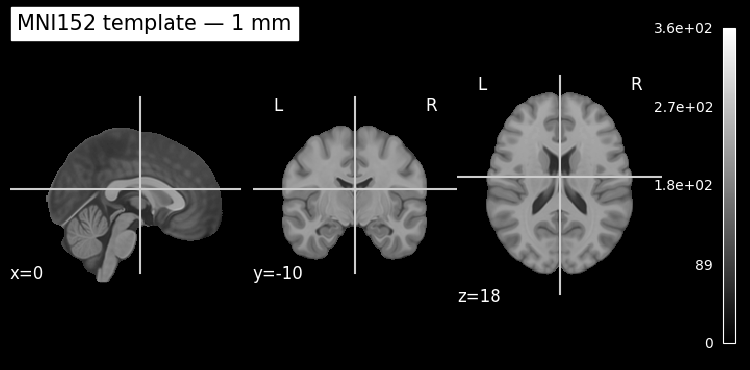

In [3]:
from nilearn import plotting

# Static orthogonal view — axial, coronal and sagittal slices at a fixed coordinate
# docs:      https://nilearn.github.io/stable/modules/generated/nilearn.plotting.plot_anat.html
plotting.plot_anat(
    img,
    title='MNI152 template — 1 mm',
    display_mode='ortho',
    cut_coords=(0, -10, 18),
    annotate=True,
)
plotting.show()

Static plots are ideal for figures in papers and reports. In the notebook, nilearn can also render an **interactive viewer** directly in the browser. 

/opt/conda/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



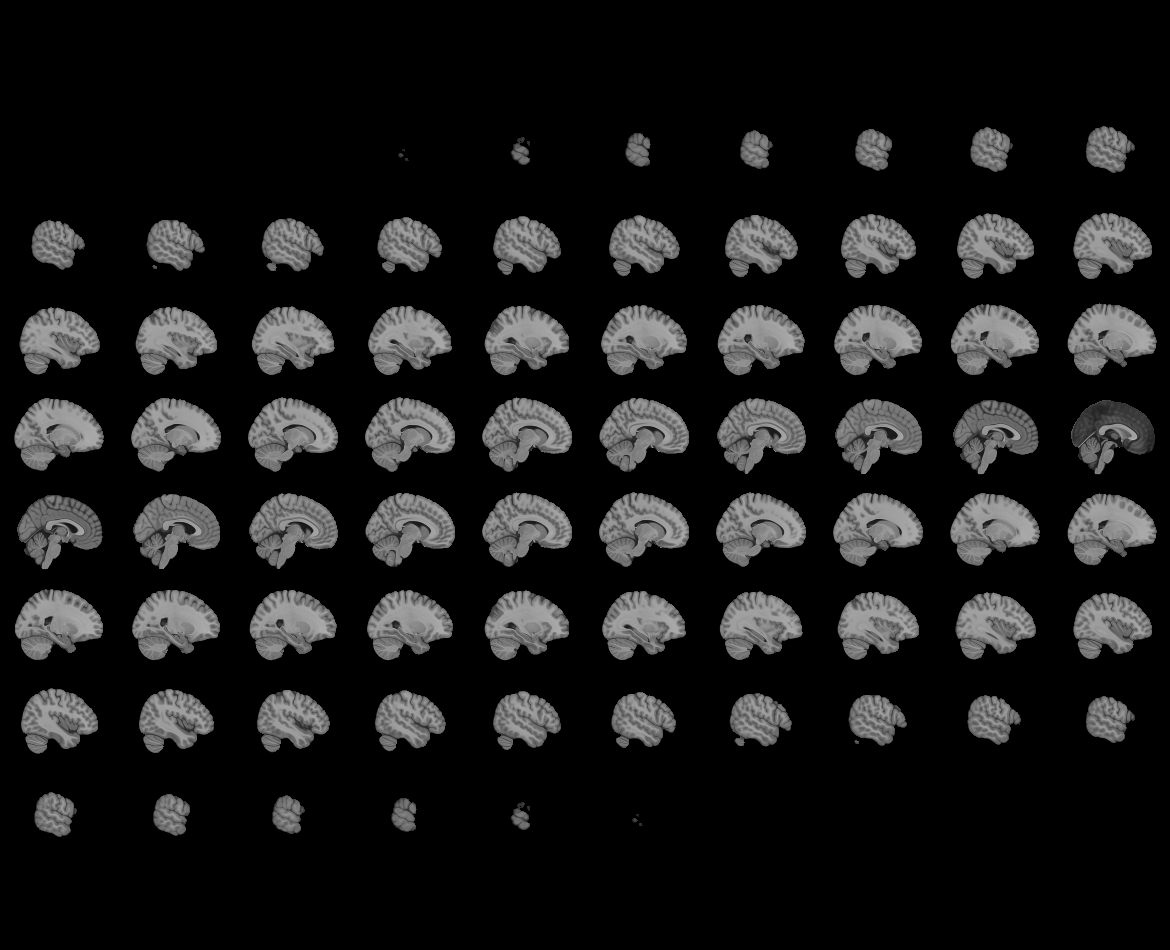
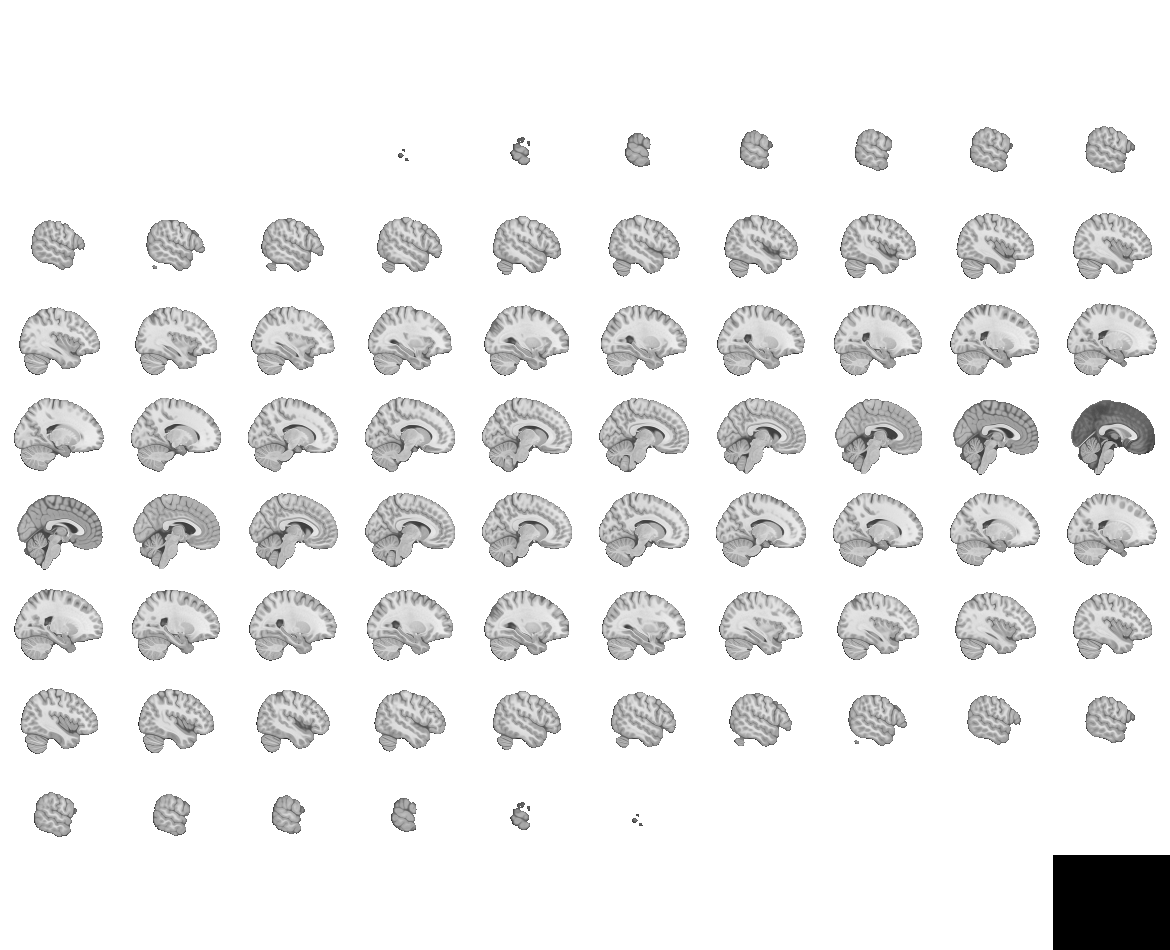

In [4]:
# Interactive HTML viewer — rendered directly in the notebook
# docs:      https://nilearn.github.io/stable/modules/generated/nilearn.plotting.view_img.html
view = plotting.view_img(
    img,
    title='MNI152 — interactive viewer',
    cut_coords=(0, -10, 18),
    colorbar=True,
    symmetric_cmap=False,
    cmap='gray',
)
view

Click anywhere to move the crosshair, exactly like MRIcron.

> 📖 **`plotting.view_img()`**: see [`nilearn.plotting.view_img`](https://nilearn.github.io/stable/modules/generated/nilearn.plotting.view_img.html); note the `cmap`, `symmetric_cmap`, `colorbar`, and `threshold` parameters. Try changing `cmap='hot'` and re-running the cell.

> **Note on T1-weighted vs BOLD:** In most neuroimaging studies you will encounter two types of MRI image. We will compare them hands-on in the exercises, but here is a quick reference.
>
> | | **T1-weighted (structural)** | **BOLD (functional)** |
> |---|---|---|
> | **Purpose** | High-resolution image of brain anatomy | Tracks brain activity over time via the BOLD signal |
> | **Dimensions** | 3D (x, y, z) | 4D (x, y, z, time) |
> | **Voxel size** | Small (~1 mm isotropic) | Larger (~2–3 mm isotropic) |
> | **Number of volumes** | 1 | Many (one per TR, typically 100–300+) |
> | **Contrast** | Distinguishes grey and white matter | Captures BOLD signal fluctuations over time |

### 2.5 🐍 Working with a brain atlas in Python

In Section 2.3 you explored the **AAL atlas** visually in MRIcron, seeing discrete integer values at each voxel and overlaying the atlas on the MNI152 template. Now we will do the same in Python: load the atlas, extract the region labels, and plot the overlay programmatically.

A **brain atlas** is a NIfTI image where each voxel stores an **integer label** identifying which brain region it belongs to, paired with a **label list** mapping each integer to a region name.

**Atlases available in nilearn (MNI space)**

nilearn ships with many standard atlases. Here is a selection:

| Function | Atlas | Regions | Type |
|---|---|---|---|
| `datasets.fetch_atlas_aal()` | AAL3v2 | 166 | Anatomical parcellation |
| `datasets.fetch_atlas_destrieux_2009()` | Destrieux | 76 | Cortical parcellation |
| `datasets.fetch_atlas_schaefer_2018()` | Schaefer | 100–1000 | Functional parcellation |
| `datasets.fetch_atlas_harvard_oxford()` | Harvard-Oxford | 96 | Probabilistic |
| `datasets.fetch_atlas_yeo_2011()` | Yeo | 7 or 17 | Functional networks |
| `datasets.fetch_atlas_basc_multiscale_2015()` | BASC | multi-scale | Functional connectivity |

→ Full list: [nilearn.datasets API reference](https://nilearn.github.io/stable/modules/reference.html#module-nilearn.datasets)

We will use the **AAL atlas** (Automated Anatomical Labeling), the same one you opened in MRIcron. We will:
1. Load the atlas and inspect its header (verify the values match what you saw in MRIcron)
2. Extract the unique label values present in the image
3. Map each value to its anatomical region name
4. Overlay the atlas on the MNI152 anatomical template

In [5]:
from nilearn import datasets, plotting
import nibabel as nib
import numpy as np

# Load the AAL atlas — the same file you opened in MRIcron in Section 2.3,
# but this time we fetch it directly from nilearn
atlas = datasets.fetch_atlas_aal()

# Print the atlas description
print(atlas.description)

[fetch_atlas_aal] Dataset found in /home/jovyan/nilearn_data/aal_3v2

.. _aal_atlas:

AAL atlas

Access
------
See :func:`nilearn.datasets.fetch_atlas_aal`.

Notes
-----
This atlas is the result of an automated anatomical :term:`parcellation`
of the spatially normalized single-subject high-resolution T1 volume
provided by the Montreal Neurological Institute (MNI)
(:footcite:t:`Collins1998`).

Using this :term:`parcellation` method, three procedures to perform the automated anatomical labeling
of functional studies are proposed:
(1) labeling of an extremum defined by a set of coordinates,
(2) percentage of voxels belonging to each of the AVOI intersected by a sphere centered by a set of coordinates, and
(3) percentage of voxels belonging to each of the AVOI intersected by an activated cluster.

For the AAL version SPM 5, 8, and 12, the map image (data.maps) contains 117 unique integer values
that define the parcellation.
However, these values are not consecutive integers from 0 to 116, as is usually the case in Nilearn.
Therefore, they should not be inter

The returned `Bunch` object (this is what nilearn returns when we call `datasets.fetch_atlas_aal()`) has three fields:

- `.maps`    — this is the path to the downloaded atlas
- `.labels`  — list of region name strings (including Background)
- `.indices` — the integer values used in the image (one per region)

In [6]:
# docs:      https://nilearn.github.io/stable/modules/generated/nilearn.datasets.fetch_atlas_aal.html
atlas_path = atlas.maps # this is the path to the downloaded atlas
print("The atlas file path is: ", atlas_path)

# Let's use nibabel to load the nifti in python
atlas_img = nib.load(atlas_path) # here we load it in python using nibabel
labels    = atlas.labels  # this extracts the label for each value in the atlas
indices   = [int(i) for i in atlas.indices]

# And let's check the header
print("Shape (i, j, k) :", atlas_img.shape)
print("Voxel size (mm)  :", atlas_img.header.get_zooms())
print("Data type        :", atlas_img.header.get_data_dtype())
print(f"Number of regions: {len(labels) - 1}")  # subtract Background
print()
print(atlas_img.header)

The atlas file path is:  /home/jovyan/nilearn_data/aal_3v2/AAL3/AAL3v1.nii
Shape (i, j, k) : (91, 109, 91)
Voxel size (mm)  : (np.float32(2.0), np.float32(2.0), np.float32(2.0))
Data type        : uint8
Number of regions: 166

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'\xff'
dim_info        : 0
dim             : [  3  91 109  91   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : label
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [-1.  2.  2.  2.  0.  0.  0.  0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 170
glmin           : 0
descrip         : b'aal3.basic.resolution'


Cross-check these values against what you noted in MRIcron; do they match?

The **data type** is an integer type: voxel values are discrete categorical labels, not continuous intensities. This is exactly what you observed in MRIcron: right-clicking through the AAL atlas gave you whole numbers. 

The **dim** array is 3D (one parcellation volume, no time dimension), and the **voxel size** is 2 mm isotropic, coarser than the 1 mm MNI152 template, which is typical for atlas parcellations.

> 📖 **Good habit: always read the docs.** Before using any nilearn function, look up its documentation page to understand what parameters it accepts and what the return value contains. Try it now for the function we just used:
>
> [`nilearn.datasets.fetch_atlas_aal()`](https://nilearn.github.io/stable/modules/generated/nilearn.datasets.fetch_atlas_aal.html).
>
> Notice the `version` parameter: what options are available, and what is the difference between them?

In [7]:
# Extract the unique integer values actually present in the atlas image
data          = atlas_img.get_fdata().astype(int) # Get the voxel values from the image, and convert to integers
unique_values = np.unique(data) # Get the unique values in the data

print(f"Unique values ({len(unique_values)} total, including 0 = background):")
print(unique_values)

Unique values (167 total, including 0 = background):
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
  74  75  76  77  78  79  80  83  84  85  86  87  88  89  90  91  92  93
  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111
 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129
 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147
 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165
 166 167 168 169 170]


All values are discrete integers, with no decimals. **0** is the background (voxels not belonging to any labelled region). All other values identify a specific brain structure. Let's map each one to its name.

In [8]:
# Build a lookup: integer value → region name
# atlas.indices pairs exactly with atlas.labels
label_dict    = dict(zip(indices, labels))
label_dict[0] = 'Background'

print(f"{'Value':>7}  Region")
print("-" * 45)
for val in sorted(label_dict):
    print(f"{val:>7}  {label_dict[val]}")

  Value  Region
---------------------------------------------
      0  Background
      1  Precentral_L
      2  Precentral_R
      3  Frontal_Sup_2_L
      4  Frontal_Sup_2_R
      5  Frontal_Mid_2_L
      6  Frontal_Mid_2_R
      7  Frontal_Inf_Oper_L
      8  Frontal_Inf_Oper_R
      9  Frontal_Inf_Tri_L
     10  Frontal_Inf_Tri_R
     11  Frontal_Inf_Orb_2_L
     12  Frontal_Inf_Orb_2_R
     13  Rolandic_Oper_L
     14  Rolandic_Oper_R
     15  Supp_Motor_Area_L
     16  Supp_Motor_Area_R
     17  Olfactory_L
     18  Olfactory_R
     19  Frontal_Sup_Medial_L
     20  Frontal_Sup_Medial_R
     21  Frontal_Med_Orb_L
     22  Frontal_Med_Orb_R
     23  Rectus_L
     24  Rectus_R
     25  OFCmed_L
     26  OFCmed_R
     27  OFCant_L
     28  OFCant_R
     29  OFCpost_L
     30  OFCpost_R
     31  OFClat_L
     32  OFClat_R
     33  Insula_L
     34  Insula_R
     37  Cingulate_Mid_L
     38  Cingulate_Mid_R
     39  Cingulate_Post_L
     40  Cingulate_Post_R
     41  Hippocampus_L
   

Each integer maps to a named anatomical region. Notice the `_L` / `_R` suffix: most structures appear twice, once per hemisphere. This bilateral structure is typical of anatomical atlases.

This is fundamentally different from the MNI152 template in Section 2.4. There, voxel values were continuous intensity levels reflecting tissue contrast. Here they are **categorical labels**: the number 41 does not mean "more signal than 40"; it means *"this voxel belongs to region 41 (Hippocampus, left)"*.

Let's now see the atlas in python, using nilearn

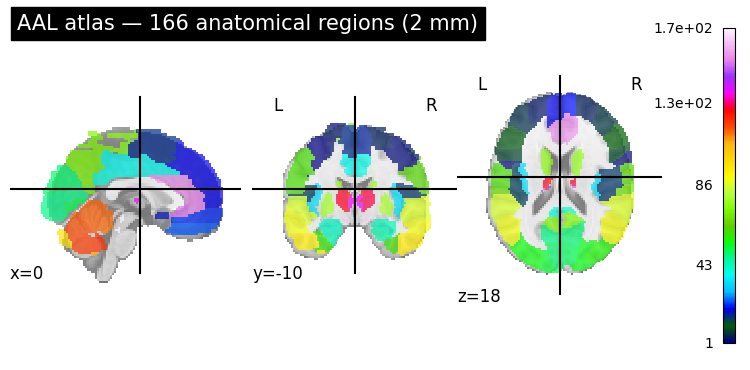

In [9]:
from nilearn import image

# --- Plot 1: atlas ---
# docs:      https://nilearn.github.io/stable/modules/generated/nilearn.plotting.plot_roi.html
# signature: plot_roi(roi_img, bg_img=..., display_mode=..., cut_coords=..., colorbar=..., alpha=...)
plotting.plot_roi(
    atlas_img,
    title='AAL atlas — 166 anatomical regions (2 mm)',
    display_mode='ortho',
    cut_coords=(0, -10, 18),
    colorbar=True,
)
plotting.show()

> 📖 **Explore further:**
> - [`nilearn.plotting.plot_roi()`](https://nilearn.github.io/stable/modules/generated/nilearn.plotting.plot_roi.html): explore `display_mode`, `cut_coords`, `cmap`, and `alpha`
> - [`nilearn.plotting` gallery](https://nilearn.github.io/stable/auto_examples/01_plotting/index.html): worked examples of every visualisation type

>**Questions:**
>
>1. How does the **data type** of the AAL atlas differ from the MNI152 template you loaded in Section 2.4? 
>
>2. The `fetch_atlas_aal()` function has a `version` parameter. Check the [documentation](https://nilearn.github.io/stable/modules/generated/nilearn.datasets.fetch_atlas_aal.html). What versions are available? What changed between them?
>
>3. Why would it be incorrect to compute the **mean voxel value** across the AAL atlas image? What would that number mean?
>4. Look at the label list: are both hemispheres represented for every region, or are there structures with only a single (non-lateralised) entry?

## 3. How do we organise (and understand) a neuroimaging dataset?

Neuroimaging datasets include data from multiple runs, sessions, and participants. On top of that, all studies are different: they adopt different experimental designs, different cohorts, different instruments, and they can perform many complex analyses. Add to this that each scientist has different skills and preferences, and you can clearly see how sharing a neuroimaging dataset that others can understand and re-use is a real challenge.

The **Brain Imaging Data Structure (BIDS)** addresses this challenge by providing a standardised set of rules for how neuroimaging data should be organised and documented. In this section, we will learn what BIDS is, why it matters, explore a real BIDS dataset, and interact with it programmatically using **pyBIDS**.

### 3.1 What is BIDS?

[**BIDS**](https://bids.neuroimaging.io/) (Brain Imaging Data Structure) is a community-developed standard that specifies exactly how neuroimaging data and associated metadata should be named, organised, and documented. Think of it as a shared language for neuroimaging datasets.

<img src="assets/sess-1a/figures/bids-paper.png" width="680" style="border: 1.5px solid black;"/>

<sub>From [Gorgolewski et al. 2016, *Scientific Data*](https://www.nature.com/articles/sdata201644).</sub>

The key principles of BIDS are: a clear **folder hierarchy**, with data organised into subject folders (`sub-XX`), optionally session folders (`ses-XX`), and subfolders for each data type (`anat`, `func`, `dwi`, `fmap`, etc.); consistent **file naming conventions** that encode key information (subject ID, session, task name, run number, modality) in a predictable, machine-readable format, as in `sub-01_ses-01_task-rest_run-01_bold.nii.gz`; **JSON sidecar files** accompanying each data file and containing acquisition parameters and other metadata; and **dataset-level documentation** in the form of `dataset_description.json` and `participants.tsv` files describing the dataset as a whole.

Why does BIDS matter? Datasets become **immediately understandable** to anyone familiar with the standard, with no custom documentation needed. BIDS **enables automated quality control and analysis** via BIDS Apps (see below). It is **required by major open data platforms** such as [OpenNeuro](https://openneuro.org/). And it promotes **reproducibility**: the data structure itself documents the experimental design, with no ambiguity about what each file contains.

### 3.2 BIDS apps: automated analysis pipelines

One of the most powerful consequences of data standardisation is that analysis tools can be written to **automatically detect and process any valid BIDS dataset**, without requiring custom configuration for each study. If your data are in BIDS, a BIDS App can just run.

**BIDS Apps** are containerised analysis pipelines (often built on the same containerisation technology as Neurodesk) that take a BIDS dataset as input and produce standardised outputs. They can be run with a single command, regardless of the dataset.

Some widely used BIDS Apps:

| BIDS App | What it does |
|---|---|
| [**fMRIPrep**](https://fmriprep.org/) | Robust, state-of-the-art preprocessing pipeline for fMRI data |
| [**MRIQC**](https://mriqc.readthedocs.io/) | Automated quality control; generates quality metrics and visual reports for each participant |
| [**FreeSurfer**](https://surfer.nmr.mgh.harvard.edu/) | Cortical surface reconstruction from T1-weighted images |

### 3.3 🖥️ From DICOM to BIDS: hands-on conversion

To make the value of BIDS concrete, we will work with **BIDScoin's official tutorial dataset**: two participants scanned on a Siemens scanner, with anatomical, functional, and field-map acquisitions.

> **Note:** the subjects in this tutorial dataset are cylindrical test phantoms, not real brains. BIDScoin ships phantom data so the focus stays on the DICOM → BIDS conversion workflow rather than anatomy — do not be surprised when the converted T1 is a cylinder!

BIDScoin provides a built-in download command. Load the BIDScoin module first — we will reuse it later in Step 4:

In [10]:
import module
await module.load('bidscoin/4.3.3')

Now we download and organise the BIDScoin dataset:

In [11]:
import shutil
from pathlib import Path

# bidscoin ships its tutorial dataset behind the `--download` flag.
# It is a CLI tool without a host-side Python API, so we invoke it via `!`.
dicom_dir = Path('results/sess-1a/01-bidscoin-example-dicom')

if not (dicom_dir / 'sub-001').exists():
    dicom_dir.mkdir(parents=True, exist_ok=True)
    !bidscoin --download {dicom_dir}

    # bidscoin creates 'bidscointutorial/raw/' (the DICOM tree) and a
    # 'bidscointutorial/bids_ref/' reference. We only need the raw DICOMs,
    # so flatten the 'raw/' subjects up to the target folder and drop the rest.
    tutorial = dicom_dir / 'bidscointutorial'
    for subject in (tutorial / 'raw').iterdir():
        shutil.move(str(subject), str(dicom_dir / subject.name))
    shutil.rmtree(tutorial)
else:
    print(f'{dicom_dir} already populated, skipping download')


results/sess-1a/01-bidscoin-example-dicom already populated, skipping download


The download creates `results/sess-1a/01-bidscoin-example-dicom/` with one subfolder per participant (`sub-001/`, `sub-002/`), each containing a session folder (`ses-01/`) with the raw DICOM series.

---

#### Step 1: explore the raw DICOM folder

Let's look at the series folders for `sub-001`:

In [12]:
! tree results/sess-1a/01-bidscoin-example-dicom/sub-001/ses-01

results/sess-1a/01-bidscoin-example-dicom/sub-001/ses-01
├── 001-localizer_32ch-head
│   ├── 00001_1.3.12.2.1107.5.2.43.66068.2020042808460132520200538.IMA
│   ├── 00002_1.3.12.2.1107.5.2.43.66068.2020042808460716296500548.IMA
│   └── 00003_1.3.12.2.1107.5.2.43.66068.2020042808460318205900543.IMA
├── 002-AAHead_Scout_32ch-head
│   ├── 00001_1.3.12.2.1107.5.2.43.66068.202004280846254557100752.IMA
│   ├── 00002_1.3.12.2.1107.5.2.43.66068.202004280846256077000772.IMA
│   ├── 00003_1.3.12.2.1107.5.2.43.66068.202004280846256185700780.IMA
│   ├── 00004_1.3.12.2.1107.5.2.43.66068.202004280846256237300784.IMA
│   ├── 00005_1.3.12.2.1107.5.2.43.66068.2020042808462512833700852.IMA
│   ├── 00006_1.3.12.2.1107.5.2.43.66068.2020042808462512887100856.IMA
│   ├── 00007_1.3.12.2.1107.5.2.43.66068.2020042808462512939500860.IMA
│   ├── 00008_1.3.12.2.1107.5.2.43.66068.2020042808462512989900864.IMA
│   ├── 00009_1.3.12.2.1107.5.2.43.66068.2020042808462514104600870.IMA
│   ├── 00010_1.3.12.2.1107.5.2.43.6

You can also open `results/sess-1a/01-bidscoin-example-dicom/` in the **VS Code Explorer** on the left (`Ctrl+Shift+E`) to browse every DICOM file, or switch to **Neurodesktop** and use its File Manager.

Each numbered folder (e.g. `007-t1_mprage_sag_ipat2_1p0iso`) is one DICOM series: the scan number, sequence name, and key parameters are all baked into the folder name. The tree contains anatomical, functional, field-map, and localizer series. 

Can you tell from the folder names alone which folder belongs to which modality?


---

#### Step 2: 🖥️ convert one series to NIfTI with MRIcron

**dcm2niix** ships with MRIcron, and it is the standard tool for converting DICOM files to NIfTI. 

We will convert just the **T1 MPRAGE for `sub-001`** (a single series) to see what dcm2niix produces before moving on to a full BIDS conversion.

First, run the next cell to create the output folder:

In [13]:
! mkdir results/sess-1a/02-mricron-dcm2nii

mkdir: cannot create directory ‘results/sess-1a/02-mricron-dcm2nii’: File exists


Now switch to **Neurodesktop** and follow these steps:

1. Open **mricronGUI** the same way we did in Section 2.2: 

   **Applications** → **Neurodesk** → **Visualisation** → **mricronGUI**. 

   From mricron's **Import** menu, open the **DICOM to NIfTI** converter (the underlying tool is `dcm2niix`; the GUI is just a front-end).

   <img src="assets/sess-1a/figures/dcm2niigui-launch.png" width="680" style="border: 1.5px solid black;"/>

2. In the converter window, set the **Output Folder** to:

   ```
   /home/jovyan/HBI/results/sess-1a/02-mricron-dcm2nii
   ```

   <img src="assets/sess-1a/figures/dcm2niigui-output.png" width="680" style="border: 1.5px solid black;"/>

3. Click **Select folder to convert** and navigate to:

   ```
   /home/jovyan/HBI/results/sess-1a/01-bidscoin-example-dicom/sub-001/ses-01/007-t1_mprage_sag_ipat2_1p0iso
   ```

   Select the folder and confirm. The converter will find the 192 DICOM slices and run the conversion automatically.

4. When the conversion finishes, come back to this notebook and list the output folder:

In [14]:
! tree results/sess-1a/02-mricron-dcm2nii

results/sess-1a/02-mricron-dcm2nii
├── 007-t1_mprage_sag_ipat2_1p0iso_t1_mprage_sag_ipat2_1p0iso_20200428084517_7.json
└── 007-t1_mprage_sag_ipat2_1p0iso_t1_mprage_sag_ipat2_1p0iso_20200428084517_7.nii

1 directory, 2 files


You should see one `.nii` file and one `.json` sidecar: the converted T1 image and its metadata. Open `results/sess-1a/02-mricron-dcm2nii/` in the **VS Code Explorer** on the left (`Ctrl+Shift+E`) and click on the `.json` sidecar to see the acquisition parameters dcm2niix extracted from the DICOM headers.

> **Questions:**
>
> - What files did MRIcron produce?
>
> - Is the output folder organised well enough for a multi-subject study with several modalities? What is missing?

---

#### Step 3: the problem: NIfTI conversion is not enough

dcm2niix (used by MRIcron) solves the **format** problem: you now have NIfTI files that any neuroimaging tool can read. But it does not solve the **organisation** problem. Files are dumped into a flat folder with no subject/session hierarchy; file names are not standardised (they come from the DICOM series description); there is no `dataset_description.json`, no `participants.tsv`, and no BIDS structure; and for several participants with multiple sessions and modalities, you would need to manually rename and sort hundreds of files.

We need a tool that handles **both** conversion and BIDS organisation.

[**BIDScoin**](https://bidscoin.readthedocs.io/) also wraps dcm2niix (like MRIcron does), and adds the BIDS organisation layer. It is itself a [**BIDS App**](https://bids.neuroimaging.io//tools/bids-apps.html) (Section 3.2): point it at a DICOM tree, and it produces a complete, valid BIDS dataset in two commands. 

First, **`bidsmapper`** scans the DICOM folder and creates a mapping from each series to its BIDS entity (modality, suffix, acquisition label, etc.). Then, **`bidscoiner`** applies the mapping to convert and organise all the data.

BIDScoin is already loaded from Step 1, so we can run the conversion directly:

In [15]:
%%bash
# The line above tells Jupyter that we want to run a terminal command instead of python code
# The line below creates a folder in results/sess-1a called 03-bidscoin-bids-conversion
mkdir -p results/sess-1a/03-bidscoin-bids-conversion

# Here below we call bidsmapper and bidscoiner. These are the two steps BIDScoin uses to
# load your DICOM files, map them into  BIDS dataset, and convert them to nifti
bidsmapper \
    results/sess-1a/01-bidscoin-example-dicom \
    results/sess-1a/03-bidscoin-bids-conversion \
    --automated

bidscoiner \
    results/sess-1a/01-bidscoin-example-dicom \
    results/sess-1a/03-bidscoin-bids-conversion

INFO | 
INFO | -------------- START BIDSmapper ------------
INFO | >>> bidsmapper sourcefolder=/home/jovyan/HBI/results/sess-1a/01-bidscoin-example-dicom bidsfolder=/home/jovyan/HBI/results/sess-1a/03-bidscoin-bids-conversion bidsmap=bidsmap.yaml template=/home/jovyan/.bidscoin/4.3.3+qt5/templates/bidsmap_dccn.yaml plugins=[] subprefix=None sesprefix=None store=False force=False
INFO | No existing bidsmap file found: /home/jovyan/HBI/results/sess-1a/03-bidscoin-bids-conversion/code/bidscoin/bidsmap.yaml
INFO | Reading: /home/jovyan/.bidscoin/4.3.3+qt5/templates/bidsmap_dccn.yaml
INFO | Checking the bidsmap run-items:
SUCCESS | All datatypes and options in the template bidsmap are valid
INFO | Mapping: /home/jovyan/HBI/results/sess-1a/01-bidscoin-example-dicom/sub-001/ses-01 (subject 1/2)
VERBOSE | Executing plugin: dcm2niix2bids -> /home/jovyan/HBI/results/sess-1a/01-bidscoin-example-dicom/sub-001/ses-01
INFO | Discovered 'exclude' DICOM sample: /home/jovyan/HBI/results/sess-1a/01-bids

BIDScoin has converted the DICOM data and organised everything into a BIDS-compliant folder. Let's see what it produced:

In [16]:
! tree results/sess-1a/03-bidscoin-bids-conversion

results/sess-1a/03-bidscoin-bids-conversion
├── README
├── code
│   └── bidscoin
│       ├── bidscoiner.errors
│       ├── bidscoiner.log
│       ├── bidscoiner.tsv
│       ├── bidsmap.yaml
│       ├── bidsmapper.errors
│       └── bidsmapper.log
├── dataset_description.json
├── participants.json
├── participants.tsv
├── sub-001
│   └── ses-01
│       ├── anat
│       │   ├── sub-001_ses-01_acq-t1mpragesagipat21p0iso_T1w.json
│       │   └── sub-001_ses-01_acq-t1mpragesagipat21p0iso_T1w.nii.gz
│       ├── fmap
│       │   ├── sub-001_ses-01_acq-fieldmap2p4iso_magnitude1.json
│       │   ├── sub-001_ses-01_acq-fieldmap2p4iso_magnitude1.nii.gz
│       │   ├── sub-001_ses-01_acq-fieldmap2p4iso_magnitude2.json
│       │   ├── sub-001_ses-01_acq-fieldmap2p4iso_magnitude2.nii.gz
│       │   ├── sub-001_ses-01_acq-fieldmap2p4iso_phasediff.json
│       │   ├── sub-001_ses-01_acq-fieldmap2p4iso_phasediff.nii.gz
│       │   ├── sub-001_ses-01_acq-fieldmap2p5iso_magnitude1.json
│       │   ├── su

Use the Explorer panel on the left to navigate to the results folder `results/sess-1a/03-bidscoin-bids-conversion`, and have a look at the folder BIDScoin produced.

As you can see, our dataset is now organised into nifti (the brain images) + JSON (metadata) files, one file per scan. The folder structure and filenames are also more clear, and they follow a standard format that can be easily shared with other scientists, or directly ingested by other BIDS Apps.

Try opening a few `.nii.gz` files, along with their json metadata file.

#### Step 5: compare DICOM vs BIDS

Look at the contrast between what we started with and what BIDScoin produced:

| | **DICOM (before)** | **BIDS (after)** |
|---|---|---|
| **Top-level structure** | `01-bidscoin-example-dicom/sub-001/ses-01/007-t1_mprage_sag_ipat2_1p0iso/` | `sub-001/ses-01/anat/` |
| **T1 files** | 192 individual `.IMA` slices in one folder | 1 `.nii.gz` + 1 `.json` sidecar |
| **BOLD files** | 10 individual `.IMA` slices per run | 1 `.nii.gz` + 1 `.json` sidecar per run |
| **Naming** | `00001_1.3.12.2.1107…IMA`, … | `sub-001_ses-01_acq-mprage_T1w.nii.gz` |
| **Metadata** | Buried inside each DICOM header | Extracted into human-readable `.json` files |
| **Documentation** | None | `dataset_description.json`, `participants.tsv` |

From hundreds of cryptically named DICOM files to a clean, self-documenting hierarchy. Any researcher familiar with BIDS can immediately understand this dataset (what participant, what session, what modality, what acquisition parameters) without any additional documentation. Open `results/sess-1a/03-bidscoin-bids-conversion/` in the **VS Code Explorer** on the left (`Ctrl+Shift+E`) to browse the full BIDS tree.

> **Questions:**
>
> 6. Open `results/sess-1a/03-bidscoin-bids-conversion/dataset_description.json` in a text editor or print it from the notebook. What information does it contain?
>
> 7. Find the T1 NIfTI file in the BIDS output. What is its full BIDS path and filename? How does this compare to the original DICOM folder name `007-t1_mprage_sag_ipat2_1p0iso/`?
>
> 8. Open the `.json` sidecar next to the T1 image. What acquisition parameters are recorded?
>
> 9. Can you also find the functional (BOLD) files? What BIDS entities are encoded in their filenames?

> 📖 **Learn more:**
>
> - [BIDScoin documentation](https://bidscoin.readthedocs.io/)
> - [Neurodesk BIDS conversion tutorial](https://neurodesk.github.io/example-notebooks/workflows/bids_conversion.html)
> - [BIDS specification](https://bids-specification.readthedocs.io/): the official standard

### 3.4 🐍 Exploring a BIDS dataset in Python: pyBIDS

Navigating a BIDS dataset manually is useful for building intuition, but the real payoff of BIDS is that **tools can read the structure automatically**. You never need to hard-code file paths, guess file names, or parse folder names by hand.

[**pyBIDS**](https://bids-standard.github.io/pybids/) is a Python library that does exactly this. It parses any BIDS dataset into a queryable Python object: you describe *what* you want (e.g. "the T1 image for subject 001") and pyBIDS finds it for you.

> 📖 **pyBIDS resources:**
> - [Documentation](https://bids-standard.github.io/pybids/)
> - [API reference: `BIDSLayout`](https://bids-standard.github.io/pybids/generated/bids.layout.BIDSLayout.html)
> - [Tutorial notebook](https://bids-standard.github.io/pybids/examples/pybids_tutorial.html)

We will:
1. Load the BIDS dataset produced by BIDScoin
2. Query it to list subjects, sessions, and modalities
3. Retrieve specific file paths by description rather than by name
4. Access the JSON sidecar metadata programmatically

In [1]:
! pip install pybids -q

In [2]:
from bids import BIDSLayout

# Load the BIDS dataset produced by BIDScoin in Section 3.3
# docs:      https://bids-standard.github.io/pybids/generated/bids.layout.BIDSLayout.html
# signature: BIDSLayout(root, validate=True, ...)
layout = BIDSLayout('results/sess-1a/03-bidscoin-bids-conversion', validate=True)

print(layout)
print(f"\nSubjects  : {layout.get_subjects()}")
print(f"Sessions  : {layout.get_sessions()}")
print(f"Datatypes : {layout.get_datatypes()}")

BIDS Layout: ...01/03-bidscoin-bids-conversion | Subjects: 2 | Sessions: 2 | Runs: 0

Subjects  : ['001', '002']
Sessions  : ['01']
Datatypes : ['anat', 'fmap', 'func']


The `BIDSLayout` object has parsed the entire dataset in one line. We can now query it:

In [3]:
# List all NIfTI files for subject 001
# docs:      https://bids-standard.github.io/pybids/generated/bids.layout.BIDSLayout.html#bids.layout.BIDSLayout.get
files = layout.get(subject='001', extension=['.nii', '.nii.gz'])

print(f"NIfTI files for sub-001 ({len(files)} total):\n")
for f in files:
    print(f"  {f.relpath}")

NIfTI files for sub-001 (15 total):

  sub-001/ses-01/anat/sub-001_ses-01_acq-t1mpragesagipat21p0iso_T1w.nii.gz
  sub-001/ses-01/fmap/sub-001_ses-01_acq-fieldmap2p4iso_magnitude1.nii.gz
  sub-001/ses-01/fmap/sub-001_ses-01_acq-fieldmap2p4iso_magnitude2.nii.gz
  sub-001/ses-01/fmap/sub-001_ses-01_acq-fieldmap2p4iso_phasediff.nii.gz
  sub-001/ses-01/fmap/sub-001_ses-01_acq-fieldmap2p5iso_magnitude1.nii.gz
  sub-001/ses-01/fmap/sub-001_ses-01_acq-fieldmap2p5iso_magnitude2.nii.gz
  sub-001/ses-01/fmap/sub-001_ses-01_acq-fieldmap2p5iso_phasediff.nii.gz
  sub-001/ses-01/func/sub-001_ses-01_task-cmrr2p4isomb8TR0700_dir-AP_bold.nii.gz
  sub-001/ses-01/func/sub-001_ses-01_task-cmrr2p4isomb8TR0700_dir-AP_sbref.nii.gz
  sub-001/ses-01/func/sub-001_ses-01_task-cmrr2p5isomb3me3TR1500_dir-AP_echo-1_bold.nii.gz
  sub-001/ses-01/func/sub-001_ses-01_task-cmrr2p5isomb3me3TR1500_dir-AP_echo-1_sbref.nii.gz
  sub-001/ses-01/func/sub-001_ses-01_task-cmrr2p5isomb3me3TR1500_dir-AP_echo-2_bold.nii.gz
  sub-001

One line of code retrieves every NIfTI file for a participant, with the correct path. Now let's be more specific:

In [5]:
# Retrieve the T1-weighted anatomical image
t1_files = layout.get(
    subject='001', 
    suffix='T1w', 
    extension=['.nii', '.nii.gz'],
    return_type='filename'
    )
print("T1w files:", t1_files)

# Retrieve the BOLD functional image
bold_files = layout.get(
    subject='001', 
    suffix='bold', 
    extension=['.nii', '.nii.gz'],
    return_type='filename'
    )
print("BOLD files:", bold_files)

T1w files: ['/home/jovyan/HBI/results/sess-1a/03-bidscoin-bids-conversion/sub-001/ses-01/anat/sub-001_ses-01_acq-t1mpragesagipat21p0iso_T1w.nii.gz']
BOLD files: ['/home/jovyan/HBI/results/sess-1a/03-bidscoin-bids-conversion/sub-001/ses-01/func/sub-001_ses-01_task-cmrr2p4isomb8TR0700_dir-AP_bold.nii.gz', '/home/jovyan/HBI/results/sess-1a/03-bidscoin-bids-conversion/sub-001/ses-01/func/sub-001_ses-01_task-cmrr2p5isomb3me3TR1500_dir-AP_echo-1_bold.nii.gz', '/home/jovyan/HBI/results/sess-1a/03-bidscoin-bids-conversion/sub-001/ses-01/func/sub-001_ses-01_task-cmrr2p5isomb3me3TR1500_dir-AP_echo-2_bold.nii.gz', '/home/jovyan/HBI/results/sess-1a/03-bidscoin-bids-conversion/sub-001/ses-01/func/sub-001_ses-01_task-cmrr2p5isomb3me3TR1500_dir-AP_echo-3_bold.nii.gz']


In [6]:
# Access metadata from the JSON sidecar
# docs:      https://bids-standard.github.io/pybids/generated/bids.layout.BIDSLayout.html#bids.layout.BIDSLayout.get_metadata
t1_entity = layout.get(
    subject='001', 
    suffix='T1w', 
    extension=['.nii', '.nii.gz']
    )[0]
metadata = t1_entity.get_metadata()

print(f"Metadata for: {t1_entity.filename}\n")

for key, value in sorted(metadata.items()):
    print(f"  {key}: {value}")

Metadata for: sub-001_ses-01_acq-t1mpragesagipat21p0iso_T1w.nii.gz

  AcquisitionMatrixPE: 256
  AcquisitionNumber: 1
  AcquisitionTime: 08:47:9.895000
  BaseResolution: 256
  BidsGuess: ['anat', '_acq-tfl3p2_run-7_T1w']
  BodyPartExamined: BRAIN
  CoilCombinationMethod: Adaptive Combine
  ConsistencyInfo: N4_VE11C_LATEST_20160120
  ConversionSoftware: dcm2niix
  ConversionSoftwareVersion: v1.0.20240202
  DeviceSerialNumber: 66068
  DwellTime: 1.5e-05
  EchoTime: 0.00303
  FlipAngle: 8
  ImageComments: Image quality: high
  ImageOrientationPatientDICOM: [0, 1, 0, 0, 0, -1]
  ImageOrientationText: Sag
  ImageType: ['ORIGINAL', 'PRIMARY', 'M', 'ND', 'NORM']
  ImagingFrequency: 123.253511
  InPlanePhaseEncodingDirectionDICOM: ROW
  InstitutionAddress: Kapittelweg 29,Nijmegen,Gelderland,NL,6525EN
  InstitutionName: Donders Centre for Cognitive Neuroimaging
  InstitutionalDepartmentName: Department
  InversionTime: 1.1
  MRAcquisitionType: 3D
  MagneticFieldStrength: 3
  Manufacturer: Sieme

All of this metadata was extracted from the DICOM headers by dcm2niix (inside BIDScoin) and stored in the `.json` sidecar file. pyBIDS simply reads it for you: no parsing, no guessing, no manual work.

**This is the payoff of BIDS.** Because the folder structure, file names, and metadata are all standardised and predictable, tools like pyBIDS can automatically find, identify, and process your data. The BIDS Apps from Section 3.2, fMRIPrep and MRIQC, use exactly the same mechanism internally: they call `BIDSLayout`, query for the files they need, and run the analysis. A BIDS App does not need to know anything about *your* study to run; it just reads the BIDS structure.

> 📖 **Explore the pyBIDS API:** Try querying the layout for different combinations of `subject`, `session`, `suffix`, `datatype`, and `extension`. What happens if you query for a modality that does not exist?

## 📝 Exercises

Now it is your turn. Using what you have learned about **nibabel**, **nilearn**, and **pyBIDS**, complete the following tasks.

---

**Exercise 1: Inspecting the BIDS-converted T1**

a. Use pyBIDS to retrieve the file path of the T1-weighted image for subject `001`.

b. Load it with nibabel and print its shape, voxel size, and data type.

c. Plot it with `nilearn.plotting.plot_anat()`.

d. Compare the dimensions to the MNI152 template from Section 2.4 (197×233×189, 1 mm). Are they the same? Why or why not?

In [ ]:
# Exercise 1 — T1 inspection


---

**Exercise 2: Inspecting the BIDS-converted BOLD**

a. Retrieve the BOLD file path with pyBIDS.

b. Load it and print its shape. How many time points (volumes) does it have?

c. Use pyBIDS to retrieve the `RepetitionTime` from the JSON metadata. What is the TR?

d. Plot the first volume using `plotting.plot_epi()`.

In [ ]:
# Exercise 2 — BOLD inspection


---

**Exercise 3: T1 vs BOLD comparison**

a. Compare the T1 and BOLD headers side by side: shape, voxel size, data type, number of dimensions.

b. Which image has higher spatial resolution? Which has a time dimension?

c. In your own words: why would a neuroimaging study typically acquire *both* a T1 and a BOLD image?

In [24]:
# Exercise 3 — T1 vs BOLD comparison

